LAb 8

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Load the Play Tennis dataset

In [3]:
df = pd.read_csv("Lab 8 - Sheet1.csv")
df.head()

,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


Separate features and target

In [4]:
X = df.drop(columns=['No', 'Play Tennis'])
y = df['Play Tennis']

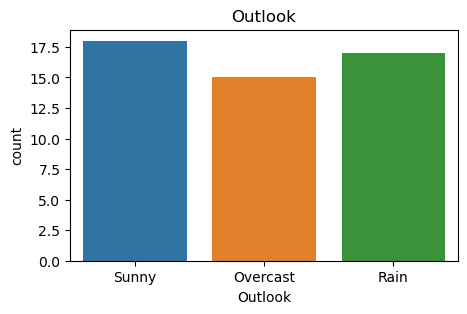

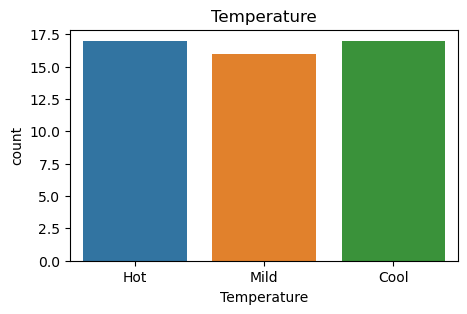

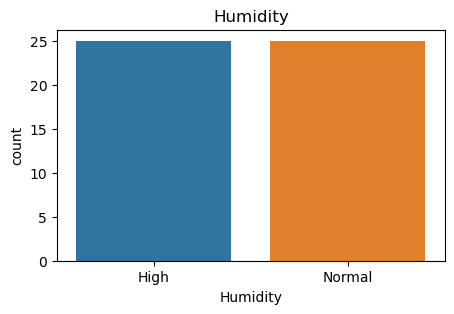

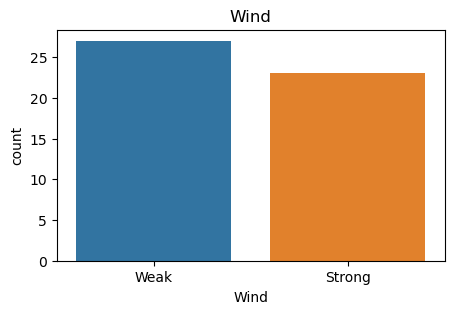

In [5]:
for col in X.columns:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()

Shows the frequency distribution of each weather attribute. This helps understand whether the dataset is balanced across different categories.

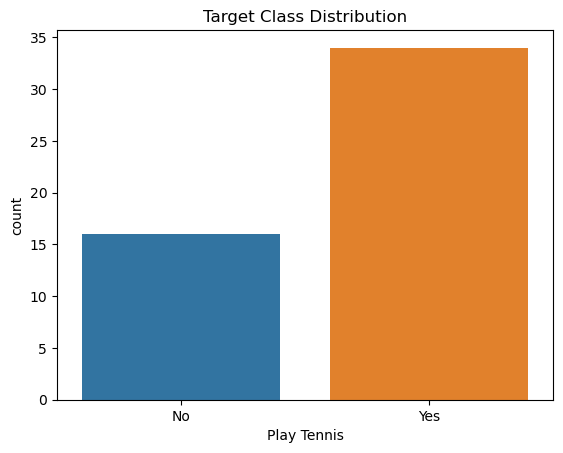

In [18]:
sns.countplot(x=df["Play Tennis"])
plt.title("Target Class Distribution")
plt.show()

The dataset contains both classes with reasonable representation, indicating no severe class imbalance.

Encode categorical data

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

oe = OrdinalEncoder()
X_encoded = pd.DataFrame(oe.fit_transform(X), columns=X.columns)


Since machine learning algorithms require numerical input, categorical values were successfully converted into numerical representations.

Train-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)
X_train_raw, X_test_raw, _, _ = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


Train Categorical Naive Bayes

In [8]:
cnb_model = CategoricalNB()
cnb_model.fit(X_train, y_train)


,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 0., ...., 8., 5.]]), array([[ 6., ...., 8., 12.]]), array([[13., ... [ 9., 17.]]), array([[ 9., ... [ 8., 18.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[14.,26.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-1.05,-0.43]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int32](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.83...-1.57553636]]), array([[-0.88...-0.80234647]]), array([[-0.13...-0.44183275]]), array([[-0.47...-0.38776553]])]"


CategoricalNB predictions and evaluation

In [9]:
y_pred_cnb = cnb_model.predict(X_test)

cnb_acc = accuracy_score(y_test, y_pred_cnb)
print(f"Categorical Naive Bayes Accuracy: {cnb_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_cnb, target_names=le.classes_))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnb))


Categorical Naive Bayes Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10

Confusion Matrix:
[[1 1]
 [1 7]]


Confusion matrix visualization

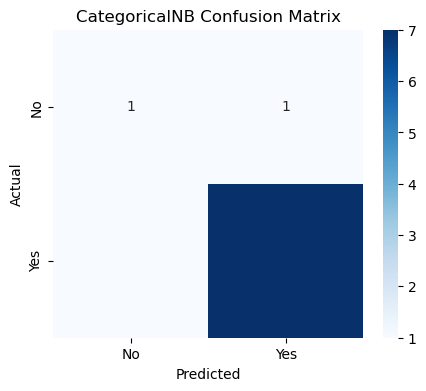

In [10]:
cm_cnb = confusion_matrix(y_test, y_pred_cnb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("CategoricalNB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The Categorical Naive Bayes model correctly classified most test instances, with only one misclassification. This indicates that the model is effective in learning patterns from the categorical Play Tennis dataset and achieved good overall performance (80% accuracy).

Predict Sunny/Cool/High/Strong sample and show class probabilities

In [11]:
sample_data = pd.DataFrame([['Sunny', 'Cool', 'High', 'Strong']], columns=['Outlook', 'Temperature', 'Humidity', 'Wind'])
sample_encoded = oe.transform(sample_data)

sample_pred = cnb_model.predict(sample_encoded)
sample_proba = cnb_model.predict_proba(sample_encoded)[0]

predicted_class = le.inverse_transform(sample_pred)[0]

print(f"Prediction for sample (Sunny, Cool, High, Strong): {predicted_class}")
print("Class Probabilities:")
for cls_name, prob in zip(le.classes_, sample_proba):
    print(f"  {cls_name}: {prob:.4f}")


Prediction for sample (Sunny, Cool, High, Strong): No
Class Probabilities:
  No: 0.9256
  Yes: 0.0744


c:\Users\NILESH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
c:\Users\NILESH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


For the given weather conditions (Sunny, Cool, High, Strong), the model predicts 'No', indicating that tennis is unlikely to be played. The probability of 92.56% for the "No" class shows high confidence in the prediction.

Train and evaluate Decision Tree

Decision Tree Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10



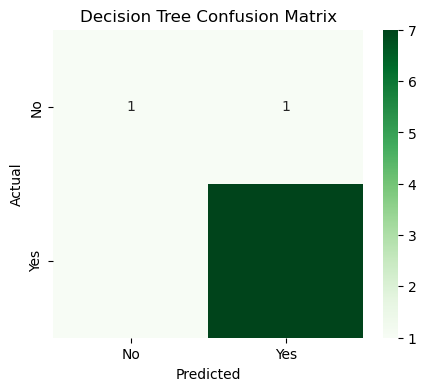

In [12]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The Decision Tree classifier achieved 80% accuracy, matching the performance of Categorical Naive Bayes. The confusion matrix shows that only one sample was incorrectly classified, demonstrating that the tree effectively captured the decision rules in the dataset.

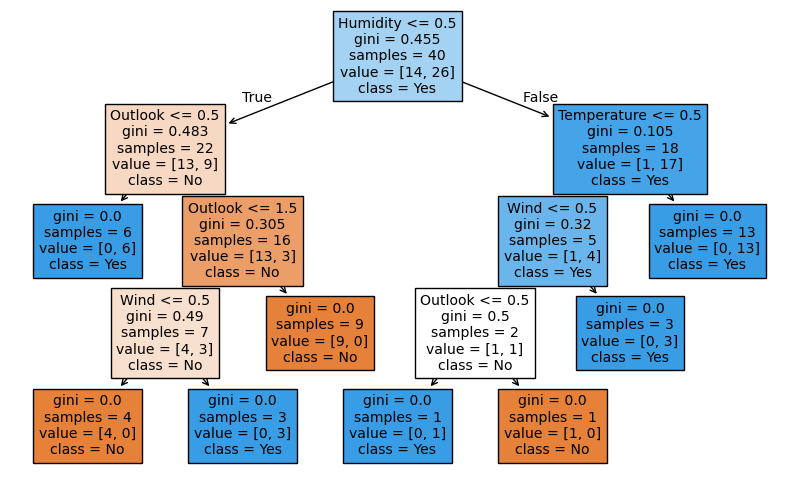

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=le.classes_,
          filled=True)
plt.show()

The tree illustrates how weather attributes influence the final prediction and provides an interpretable model.

Train and evaluate Logistic Regression

Logistic Regression Accuracy: 0.7000

Classification Report:
              precision    recall  f1-score   support

          No       0.33      0.50      0.40         2
         Yes       0.86      0.75      0.80         8

    accuracy                           0.70        10
   macro avg       0.60      0.62      0.60        10
weighted avg       0.75      0.70      0.72        10



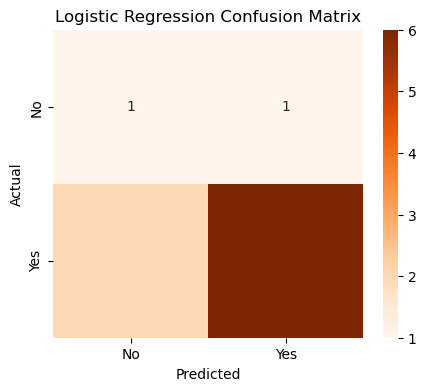

In [13]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train_raw)
X_test_ohe = ohe.transform(X_test_raw)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_ohe, y_train)

y_pred_lr = lr_model.predict(X_test_ohe)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Logistic Regression achieved 70% accuracy, which is lower than both Categorical Naive Bayes and Decision Tree. This suggests that a linear model is less suitable for this categorical dataset, resulting in more misclassifications.

Create model performance comparison table

In [14]:
comparison_df = pd.DataFrame({
    'Model': ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [cnb_acc, dt_acc, lr_acc]
})
print("Model Comparison Table:")
print(comparison_df.to_string(index=False))


Model Comparison Table:
                  Model  Accuracy
Categorical Naive Bayes       0.8
          Decision Tree       0.8
    Logistic Regression       0.7


The comparison shows that Categorical Naive Bayes and Decision Tree both achieved the highest accuracy of 80%, while Logistic Regression achieved 70%. This indicates that models specifically designed for categorical data or rule-based learning perform better on the Play Tennis dataset.

Plot accuracy comparison

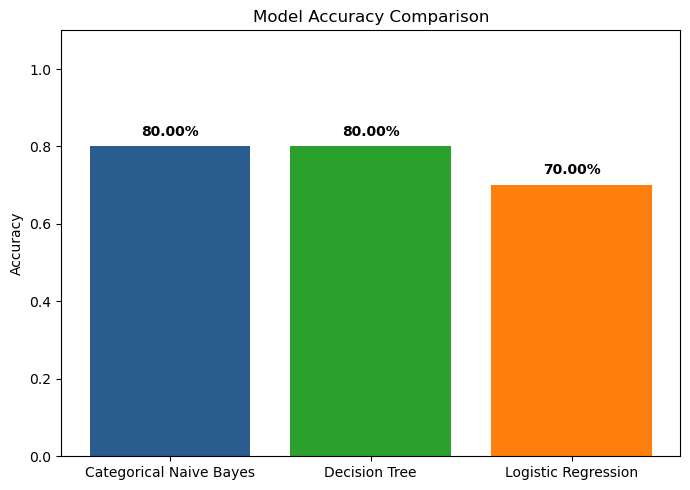

In [15]:
plt.figure(figsize=(7, 5))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#2b5c8f', '#2ca02c', '#ff7f0e'])
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2%}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


The bar chart provides a visual comparison of model performance. Categorical Naive Bayes and Decision Tree achieved equal highest accuracy (80%), whereas Logistic Regression performed slightly lower (70%).

Display best-performing model

In [16]:
best_row = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"Best Performing Model: {best_row['Model']} with an accuracy of {best_row['Accuracy']:.2%}")


Best Performing Model: Categorical Naive Bayes with an accuracy of 80.00%


Based on the evaluation metric, Categorical Naive Bayes was selected as the best-performing model with 80% accuracy. Although Decision Tree achieved the same accuracy, Categorical Naive Bayes is more suitable for categorical datasets and was therefore selected.

In [17]:
test_sizes = [0.2, 0.25, 0.3]
random_states = [42, 10, 20, 100, 7]

results = []

for ts in test_sizes:
    for rs in random_states:
        X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(X, y_encoded, test_size=ts, random_state=rs)
        
        oe_exp = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_tr_ord = oe_exp.fit_transform(X_tr_raw)
        X_te_ord = oe_exp.transform(X_te_raw)
        
        model_cnb = CategoricalNB()
        model_cnb.fit(X_tr_ord, y_tr)
        acc_cnb = accuracy_score(y_te, model_cnb.predict(X_te_ord))
        
        model_dt = DecisionTreeClassifier(random_state=rs)
        model_dt.fit(X_tr_ord, y_tr)
        acc_dt = accuracy_score(y_te, model_dt.predict(X_te_ord))
        
        ohe_exp = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_tr_ohe = ohe_exp.fit_transform(X_tr_raw)
        X_te_ohe = ohe_exp.transform(X_te_raw)
        
        model_lr = LogisticRegression(random_state=rs)
        model_lr.fit(X_tr_ohe, y_tr)
        acc_lr = accuracy_score(y_te, model_lr.predict(X_te_ohe))
        
        results.append({
            'test_size': ts,
            'random_state': rs,
            'CategoricalNB': acc_cnb,
            'DecisionTree': acc_dt,
            'LogisticRegression': acc_lr
        })

experiment_df = pd.DataFrame(results)
print("Experiment Results across Multiple Splits:")
print(experiment_df.to_string(index=False))

avg_accuracies = experiment_df[['CategoricalNB', 'DecisionTree', 'LogisticRegression']].mean()
std_accuracies = experiment_df[['CategoricalNB', 'DecisionTree', 'LogisticRegression']].std()

print("\n--- Average Accuracy across Splits ---")
for model_name, avg_acc in avg_accuracies.items():
    print(f"{model_name}: {avg_acc:.4f} (Std Dev: {std_accuracies[model_name]:.4f})")

best_avg_model = avg_accuracies.idxmax()
most_consistent_model = std_accuracies.idxmin()

print(f"\nModel with highest average accuracy: {best_avg_model} ({avg_accuracies[best_avg_model]:.2%})")
print(f"Model with most consistent performance (lowest std dev): {most_consistent_model} (Std Dev: {std_accuracies[most_consistent_model]:.4f})")


Experiment Results across Multiple Splits:
 test_size  random_state  CategoricalNB  DecisionTree  LogisticRegression
      0.20            42       0.800000      0.800000            0.700000
      0.20            10       0.900000      0.800000            0.900000
      0.20            20       0.900000      0.900000            0.900000
      0.20           100       0.900000      1.000000            0.900000
      0.20             7       0.900000      0.900000            1.000000
      0.25            42       0.846154      0.846154            0.769231
      0.25            10       0.923077      0.846154            0.923077
      0.25            20       0.923077      0.923077            0.923077
      0.25           100       0.923077      1.000000            0.923077
      0.25             7       0.923077      0.923077            0.923077
      0.30            42       0.800000      0.600000            0.800000
      0.30            10       1.000000      0.866667            0.86

The experiment evaluated all three models using different train-test splits and random states. Categorical Naive Bayes achieved the highest average accuracy (88.48%) with the lowest standard deviation (0.0663), indicating that it is both the most accurate and the most consistent model across different dataset partitions. Decision Tree showed comparable accuracy but greater variation, while Logistic Regression produced the lowest average performance.